In [1]:
# Martin Konečnik, https://git.siwim.si/machine-learning/fix-qa-binary-classification
# Notebook intended for prototyping binary classification models
import pickle
import random
import tomllib
from pathlib import Path
from typing import List, Tuple

import numpy as np
import torch
from sklearn.model_selection import train_test_split
from swm import factory
from torch.utils.data import DataLoader, TensorDataset

# Initialize CUDA.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
# Set seeds
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

In [3]:
# Read the configuration file.
with open('conf.toml', 'rb') as f:
    conf = tomllib.load(f)

EVENTS_PATH = Path().home() / conf['data_dir'] / 'prepared'
FIRST_CHANNEL = conf['first_channel']
LAST_CHANNEL = conf['last_channel']
LOAD_EVENTS = conf.get('load_events', False)
EPOCHS = conf['epoch']
LR = conf['lr']
BATCH = conf['batch']
SEEDS = conf['seeds']

In [4]:
# TODO Feels like signals_unaltered and signals_corrected should be np arrays, but cba changing that now.
unaltered_pkl_path = EVENTS_PATH / 'unaltered.pkl'
corrected_pkl_path = EVENTS_PATH / 'corrected.pkl'
if LOAD_EVENTS or not unaltered_pkl_path.exists() or not corrected_pkl_path.exists():  # To save time event files are only read if pkl files don't exist or if explicitly set in the toml file.
    # Read the event files.
    signals_unaltered = [[] for _ in range(FIRST_CHANNEL, LAST_CHANNEL + 1)]  # Initializes an empty list for each channel.
    signals_corrected = [[] for _ in range(FIRST_CHANNEL, LAST_CHANNEL + 1)]
    binary_labels = []
    for event in (EVENTS_PATH / 'unaltered' / '0').iterdir():
        data = factory.read_file(event)
        for ch in range(FIRST_CHANNEL, LAST_CHANNEL + 1):
            signals_unaltered[ch].append(data.acqdata.a[ch].data)
    with open(unaltered_pkl_path, 'wb') as f:
        pickle.dump(signals_unaltered, f)

    for event in (EVENTS_PATH / 'corrected' / '0').iterdir():
        data = factory.read_file(event)
        for ch in range(FIRST_CHANNEL, LAST_CHANNEL + 1):
            signals_corrected[ch].append(data.acqdata.a[ch].data)
    with open(corrected_pkl_path, 'wb') as f:
        pickle.dump(signals_corrected, f)
else:
    # Read the pickled arrays.
    with open(unaltered_pkl_path, 'rb') as f:
        signals_unaltered = pickle.load(f)
    with open(corrected_pkl_path, 'rb') as f:
        signals_corrected = pickle.load(f)

In [5]:
print(f'Number of channels: {len(signals_unaltered)}.')
print(f'Unaltered signals: {len(signals_unaltered[0])}.')
print(f'Corrected signals: {len(signals_corrected[0])}.')

Number of channels: 8.
Unaltered signals: 60309.
Corrected signals: 1192.


In [6]:
def splice(my_list: List[float], index: int, signal_length: int) -> Tuple[np.array, np.array]:
    """
    Split signals into two arrays.
    :param my_list: List of signals to be processed.
    :param index: Index on which the lists are split.
    :param signal_length: Maximum length of a signal.
    :return:
    """
    result = [[] for _ in range(len(my_list))]
    print(f'Processing {len(my_list)} channels ...')
    for i, veh in enumerate(my_list):
        print(f'Processing {len(veh)} signals for channel {i} ...')
        for signal in veh:  # Normalize the signals.
            result[i].append(np.pad(signal - signal[0], (0, signal_length - len(signal)), mode='edge'))
    return np.array([sublist[:index] for sublist in result]), np.array([sublist[index:] for sublist in result])


# Split signals into training and testing sets.
num_signals = len(signals_unaltered)
max_length = max(len(signal) for signal in signals_unaltered[0] + signals_corrected[0])

signals_unaltered, test_unaltered = splice(signals_unaltered, -200, max_length)
signals_corrected, test_corrected = splice(signals_corrected, -100, max_length)

Processing 8 channels ...
Processing 60309 signals for channel 0 ...
Processing 60309 signals for channel 1 ...
Processing 60309 signals for channel 2 ...
Processing 60309 signals for channel 3 ...
Processing 60309 signals for channel 4 ...
Processing 60309 signals for channel 5 ...
Processing 60309 signals for channel 6 ...
Processing 60309 signals for channel 7 ...
Processing 8 channels ...
Processing 1192 signals for channel 0 ...
Processing 1192 signals for channel 1 ...
Processing 1192 signals for channel 2 ...
Processing 1192 signals for channel 3 ...
Processing 1192 signals for channel 4 ...
Processing 1192 signals for channel 5 ...
Processing 1192 signals for channel 6 ...
Processing 1192 signals for channel 7 ...


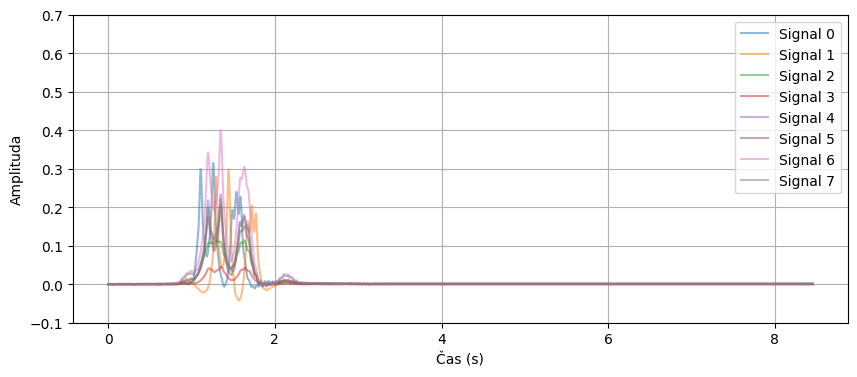

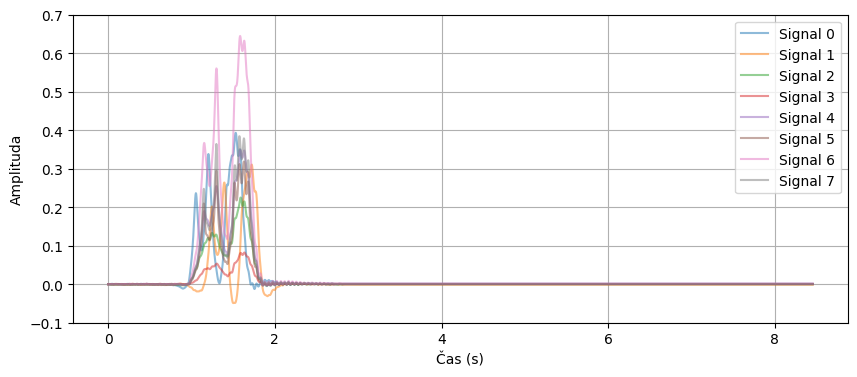

In [7]:
# Sample signal
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
for i in range(num_signals):
    plt.plot(np.arange(max_length) / 512, signals_unaltered[i][0], label=f'Signal {i}', alpha=0.5)
plt.xlabel('Čas (s)')
plt.ylabel('Amplituda')
plt.ylim(-0.1, 0.7)
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
for i in range(num_signals):
    plt.plot(np.arange(max_length) / 512, signals_corrected[i][2], label=f'Signal {i}', alpha=0.5)
plt.xlabel('Čas (s)')
plt.ylabel('Amplituda')
plt.ylim(-0.1, 0.7)
plt.grid(True)
plt.legend()
plt.show()

In [8]:
# Average out all the signals
# Generate additional corrected signals bi removing channels.
# avg_all = np.mean(signals_corrected, axis=0)
# avg_no_ch1 = np.mean(signals_corrected[1:, :, :], axis=0)  # Remove channel 1
# avg_no_ch8 = np.mean(signals_corrected[:-1, :, :], axis=0)  # Remove channel 8
#
# # Concatenate (now we can reassign)
# signals_corrected = np.concatenate([avg_all, avg_no_ch1, avg_no_ch8], axis=0)
signals_corrected = np.mean(signals_corrected, axis=0)

# We have enough of unaltered signals to train on.
signals_unaltered = np.mean(signals_unaltered, axis=0)

In [9]:
num_corrected = len(signals_corrected)  # This value represents the number of samples for each class.
num_unaltered = 2 * num_corrected
print(f'Number of signals: {num_signals}.')
print(f'Max length: {max_length}.')
print(f'Number of corrected: {num_corrected}.')
print(f'Number of unaltered: {num_corrected}.')

print(f'Corrected shape: {signals_corrected.shape}')
print(f'Unaltered shape: {signals_unaltered.shape}')

Number of signals: 8.
Max length: 4329.
Number of corrected: 1092.
Number of unaltered: 1092.
Corrected shape: (1092, 4329)
Unaltered shape: (60109, 4329)


In [ ]:
from sklearn.metrics import precision_score, recall_score
from classifier import BinaryClassifier

MODEL = 'classifier'

torch.cuda.empty_cache()

results = {}

# Train the model with different seeds.
for seed in SEEDS:
    print('=' * 60)
    print(f'Running for seed: {seed}')
    results[seed] = {}
    set_seed(seed)

    total_available = len(signals_unaltered[0])
    unaltered = random.sample(range(total_available), num_unaltered)  # Add double number of samples for unaltered class
    signals = np.vstack((np.empty((num_unaltered, max_length)), signals_corrected))  # Create numpy array with empty space for unaltered signals

    for i, sample in enumerate(unaltered):  # Add unaltered signals to the array.
        signals[i] = signals_unaltered[sample]

    binary_labels = np.array([0] * num_unaltered + [1] * num_corrected)

    # Split indices into train/validation
    train_idx, val_idx = train_test_split(
        np.arange(len(signals)),  # Split the indices
        test_size=0.2,
        random_state=seed  # Always set random state for reproducibility
    )

    X_tensor = torch.from_numpy(signals).unsqueeze(1).to(device)  # Unsqueeze is done to ensure tensor dimensions are correct for conv1d to work properly.
    y_tensor = torch.from_numpy(binary_labels).to(device)

    # Create dataset
    full_dataset = TensorDataset(X_tensor, y_tensor)
    # Create train/test datasets using the indices we split earlier
    train_dataset = torch.utils.data.Subset(full_dataset, train_idx)
    val_dataset = torch.utils.data.Subset(full_dataset, val_idx)

    torch.multiprocessing.set_start_method('spawn', force=True)

    for batch_size in BATCH:
        print(f'With batch size: {batch_size}')
        results[seed][batch_size] = {}
        # Prepare DataLoaders
        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            generator=torch.Generator().manual_seed(seed)
        )
        val_loader = DataLoader(
            val_dataset,
            batch_size=batch_size
        )

        for lr in LR:
            print(f'With LR: {lr}')
            results[seed][batch_size][lr] = {}

            for num_epochs in EPOCHS:
                print(f'With epoch: {num_epochs}')
                results[seed][batch_size][lr][num_epochs] = {
                    'train_loss': [],
                    'val_loss': []
                }
                model = BinaryClassifier(max_length).to(device)
                criterion = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([num_unaltered / num_corrected]).to(device))  # Binary Cross Entropy Loss
                optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
                scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)

                for epoch in range(num_epochs):
                    model.train()
                    running_loss = 0.0

                    for inputs, labels in train_loader:
                        optimizer.zero_grad()
                        outputs = model(inputs.float()).squeeze()
                        loss = criterion(outputs, labels.float())
                        loss.backward()
                        optimizer.step()
                        running_loss += loss.item()

                    results[seed][batch_size][lr][num_epochs]['train_loss'].append(running_loss / len(train_loader))

                    model.eval()
                    val_running_loss = 0.0

                    with torch.no_grad():
                        for inputs, labels in val_loader:
                            outputs = model(inputs.float()).squeeze()
                            loss = criterion(outputs, labels.float())
                            val_running_loss += loss.item()

                    results[seed][batch_size][lr][num_epochs]['val_loss'].append(val_running_loss / len(val_loader))

                # Final loss
                print(f'Final train Loss: {results[seed][batch_size][lr][num_epochs]['train_loss'][-1]:.4f}, Final val Loss: {results[seed][batch_size][lr][num_epochs]['val_loss'][-1]:.4f}')

                model.eval()
                with torch.no_grad():
                    correct = 0
                    total = 0
                    all_preds = []
                    all_labels = []

                    for inputs, labels in val_loader:
                        outputs = model(inputs.float())
                        predicted = (outputs > 0.5).float()
                        all_preds.extend(predicted.squeeze().cpu().numpy())
                        all_labels.extend(labels.cpu().numpy())

                    # Metrics
                    precision = precision_score(all_labels, all_preds, zero_division=0)
                    recall = recall_score(all_labels, all_preds, zero_division=0)

                    print(f'Precision: {precision:.4f}')
                    print(f'Recall: {recall:.4f}')

                    results[seed][batch_size][lr][num_epochs]['precision'] = precision
                    results[seed][batch_size][lr][num_epochs]['recall'] = recall
                torch.cuda.empty_cache()

Running for seed: 1


In [ ]:
# Save the results to file
import json

with open('complete_results.json', 'w') as f:
    json.dump(results, f)

In [25]:
# Average metrics
print("\n" + "=" * 80)
print("Averages after all iterations")
print("=" * 80)

for batch_size in BATCH:
    for lr in LR:
        for num_epochs in EPOCHS:
            precisions = []
            recalls = []
            final_train_losses = []
            final_val_losses = []

            for seed in results:
                metrics = results[seed][batch_size][lr][num_epochs]

                precisions.append(metrics.get('precision', 0))
                recalls.append(metrics.get('recall', 0))

                # Končni loss (zadnja epoha)
                train_loss = metrics.get('train_loss', [])
                val_loss = metrics.get('val_loss', [])
                if train_loss:
                    final_train_losses.append(train_loss[-1])
                if val_loss:
                    final_val_losses.append(val_loss[-1])

        # Izračun povprečij in standardnih odklonov
        mean_prec = np.mean(precisions)
        std_prec = np.std(precisions)
        mean_recall = np.mean(recalls)
        std_recall = np.std(recalls)
        mean_train_loss = np.mean(final_train_losses)
        std_train_loss = np.std(final_train_losses)
        mean_val_loss = np.mean(final_val_losses)
        std_val_loss = np.std(final_val_losses)

        print(f"\n📊 BS={batch_size}, LR={lr}, Epochs={num_epochs}")
        print(f"   Precision: {mean_prec:.4f} ± {std_prec:.4f}")
        print(f"   Recall: {mean_recall:.4f} ± {std_recall:.4f}")
        print(f"   Train Loss: {mean_train_loss:.4f} ± {std_train_loss:.4f}")
        print(f"   Val Loss: {mean_val_loss:.4f} ± {std_val_loss:.4f}")


Averages after all iterations

📊 BS=16, LR=0.0005, Epochs=100
   Precision: 0.8725 ± 0.0327
   Recall: 0.6887 ± 0.0810
   Train Loss: 0.3306 ± 0.0115
   Val Loss: 0.3211 ± 0.0341

📊 BS=16, LR=0.001, Epochs=100
   Precision: 0.8362 ± 0.0816
   Recall: 0.6546 ± 0.0767
   Train Loss: 0.3652 ± 0.0169
   Val Loss: 0.3767 ± 0.0506

📊 BS=16, LR=0.003, Epochs=100
   Precision: 0.8523 ± 0.0503
   Recall: 0.5270 ± 0.0837
   Train Loss: 0.3950 ± 0.0216
   Val Loss: 0.4008 ± 0.0290

📊 BS=16, LR=0.005, Epochs=100
   Precision: 0.8463 ± 0.0355
   Recall: 0.5353 ± 0.0414
   Train Loss: 0.4137 ± 0.0116
   Val Loss: 0.4081 ± 0.0201

📊 BS=32, LR=0.0005, Epochs=100
   Precision: 0.8606 ± 0.0212
   Recall: 0.6573 ± 0.0590
   Train Loss: 0.3331 ± 0.0294
   Val Loss: 0.3404 ± 0.0326

📊 BS=32, LR=0.001, Epochs=100
   Precision: 0.8616 ± 0.0249
   Recall: 0.6280 ± 0.0815
   Train Loss: 0.3624 ± 0.0204
   Val Loss: 0.3742 ± 0.0335

📊 BS=32, LR=0.003, Epochs=100
   Precision: 0.8634 ± 0.0489
   Recall: 0.5523 

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# ZBIRANJE PODATKOV IZ results SLOVARJA
# ============================================================

# Zbiranje vseh kombinacij
learning_rates = sorted(set([lr for seed in results for bs in results[seed] for lr in results[seed][bs]]))
batch_sizes = sorted(set([bs for seed in results for bs in results[seed]]))
epochs_list = sorted(set([ep for seed in results for bs in results[seed] for lr in results[seed][bs] for ep in results[seed][bs][lr]]))

combinations = [(bs, ep) for bs in batch_sizes for ep in epochs_list]
combination_labels = [f'{bs}, {ep}' for bs, ep in combinations]

# Matrike za povprečne vrednosti
train_loss_matrix = np.zeros((len(learning_rates), len(batch_sizes)))
val_loss_matrix = np.zeros((len(learning_rates), len(batch_sizes)))
train_loss_std_matrix = np.zeros((len(learning_rates), len(batch_sizes)))
val_loss_std_matrix = np.zeros((len(learning_rates), len(batch_sizes)))

# Matrike za metrike
recall_matrix = np.zeros((len(learning_rates), len(batch_sizes)))
recall_std_matrix = np.zeros((len(learning_rates), len(batch_sizes)))

for i, lr in enumerate(learning_rates):
    for j, bs in enumerate(batch_sizes):
        train_losses = []
        val_losses = []
        recalls = []

        for seed in results:
            if bs in results[seed] and lr in results[seed][bs]:
                for num_epochs in results[seed][bs][lr]:
                    data = results[seed][bs][lr][num_epochs]

                    # Končni loss (zadnja epoha)
                    train_loss = data['train_loss']
                    val_loss = data['val_loss']
                    if isinstance(train_loss, list):
                        train_loss = train_loss[-1]
                    if isinstance(val_loss, list):
                        val_loss = val_loss[-1]

                    train_losses.append(train_loss)
                    val_losses.append(val_loss)
                    recalls.append(data.get('recall', 0))

        # Povprečja in standardni odkloni
        if train_losses:
            train_loss_matrix[i, j] = np.mean(train_losses)
            train_loss_std_matrix[i, j] = np.std(train_losses)
            val_loss_matrix[i, j] = np.mean(val_losses)
            val_loss_std_matrix[i, j] = np.std(val_losses)
            recall_matrix[i, j] = np.mean(recalls)
            recall_std_matrix[i, j] = np.std(recalls)

# ============================================================
# TABELA Z VSEMI REZULTATI
# ============================================================
print("\n" + "=" * 120)
print("TABELA REZULTATOV ZA VSE KOMBINACIJE HIPERPARAMETROV")
print("=" * 120)

# Ustvari podatke za pandas DataFrame
table_data = []
for i, lr in enumerate(learning_rates):
    for j, bs in enumerate(batch_sizes):
        if not np.isnan(train_loss_matrix[i, j]):
            table_data.append({
                'LR': lr,
                'Batch': bs,
                'Učna izguba': f"{train_loss_matrix[i, j]:.3f} ± {train_loss_std_matrix[i, j]:.3f}",
                'Validacijska izguba': f"{val_loss_matrix[i, j]:.3f} ± {val_loss_std_matrix[i, j]:.3f}",
                'Recall': f"{recall_matrix[i, j]:.3f} ± {recall_std_matrix[i, j]:.3f}"
            })

df = pd.DataFrame(table_data)
print(df.to_string(index=False))

# ============================================================
# NAJBOLJŠE KOMBINACIJE
# ============================================================
print("\n" + "=" * 80)
print("NAJBOLJŠE KOMBINACIJE PO POSAMEZNIH METRIKAH")
print("=" * 80)

# Najboljši recall
best_recall_idx = np.unravel_index(np.argmax(recall_matrix), recall_matrix.shape)
print(f"\n🏆 Najboljši recall: {recall_matrix[best_recall_idx]:.3f} ± {recall_std_matrix[best_recall_idx]:.3f}")
print(f"   LR={learning_rates[best_recall_idx[0]]}, Batch={batch_sizes[best_recall_idx[1]]}")

# Najnižji val loss
best_val_idx = np.unravel_index(np.argmin(val_loss_matrix), val_loss_matrix.shape)
print(f"\n🏆 Najnižji val loss: {val_loss_matrix[best_val_idx]:.3f} ± {val_loss_std_matrix[best_val_idx]:.3f}")
print(f"   LR={learning_rates[best_val_idx[0]]}, Batch={batch_sizes[best_val_idx[1]]}")

# ============================================================
# SHRAJE VANJE V CSV
# ============================================================
df.to_csv('hyperparameter_results.csv', index=False)
print("\n✅ Rezultati shranjeni v 'hyperparameter_results.csv'")


TABELA REZULTATOV ZA VSE KOMBINACIJE HIPERPARAMETROV
    LR  Batch   Učna izguba Validacijska izguba        Recall
0.0005     16 0.331 ± 0.012       0.321 ± 0.034 0.689 ± 0.081
0.0005     32 0.333 ± 0.029       0.340 ± 0.033 0.657 ± 0.059
0.0005     64 0.335 ± 0.021       0.369 ± 0.046 0.698 ± 0.106
0.0010     16 0.365 ± 0.017       0.377 ± 0.051 0.655 ± 0.077
0.0010     32 0.362 ± 0.020       0.374 ± 0.033 0.628 ± 0.082
0.0010     64 0.364 ± 0.023       0.379 ± 0.024 0.648 ± 0.075
0.0030     16 0.395 ± 0.022       0.401 ± 0.029 0.527 ± 0.084
0.0030     32 0.374 ± 0.012       0.389 ± 0.039 0.552 ± 0.118
0.0030     64 0.374 ± 0.012       0.365 ± 0.037 0.572 ± 0.068
0.0050     16 0.414 ± 0.012       0.408 ± 0.020 0.535 ± 0.041
0.0050     32 0.391 ± 0.016       0.389 ± 0.035 0.585 ± 0.062
0.0050     64 0.388 ± 0.013       0.419 ± 0.073 0.605 ± 0.098

NAJBOLJŠE KOMBINACIJE PO POSAMEZNIH METRIKAH

🏆 Najboljši recall: 0.698 ± 0.106
   LR=0.0005, Batch=64

🏆 Najnižji val loss: 0.321 ± 0.034


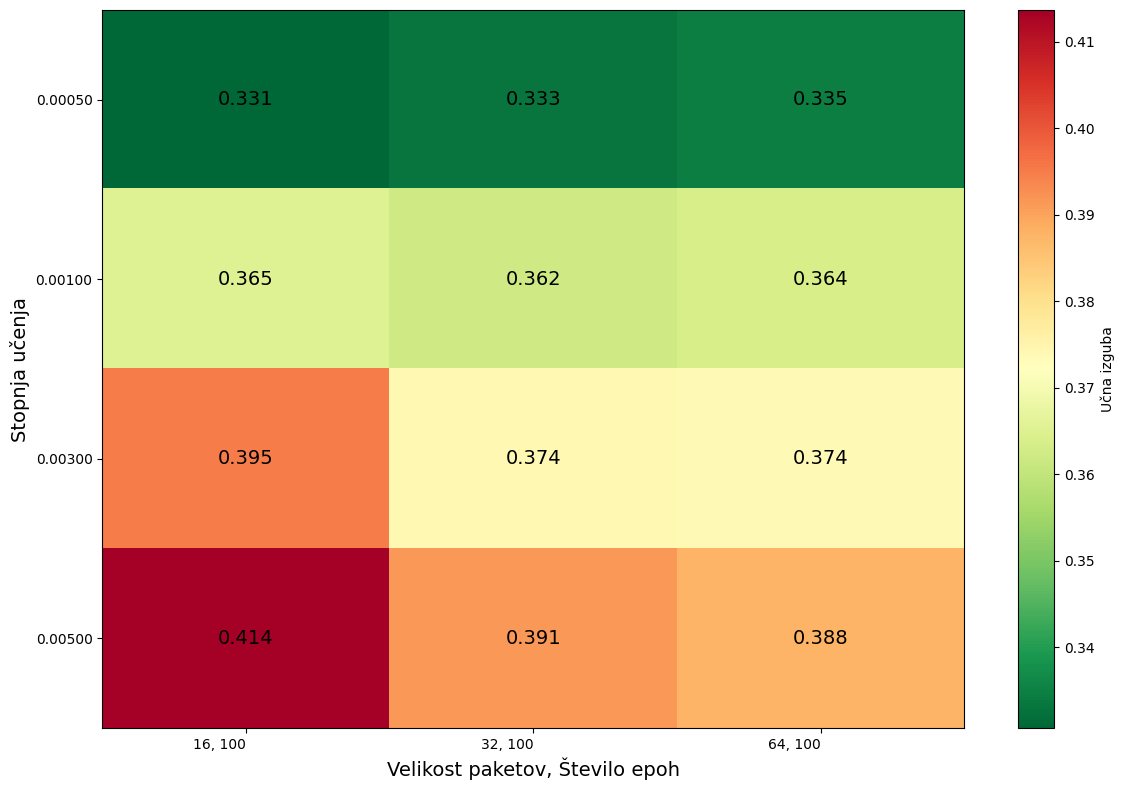

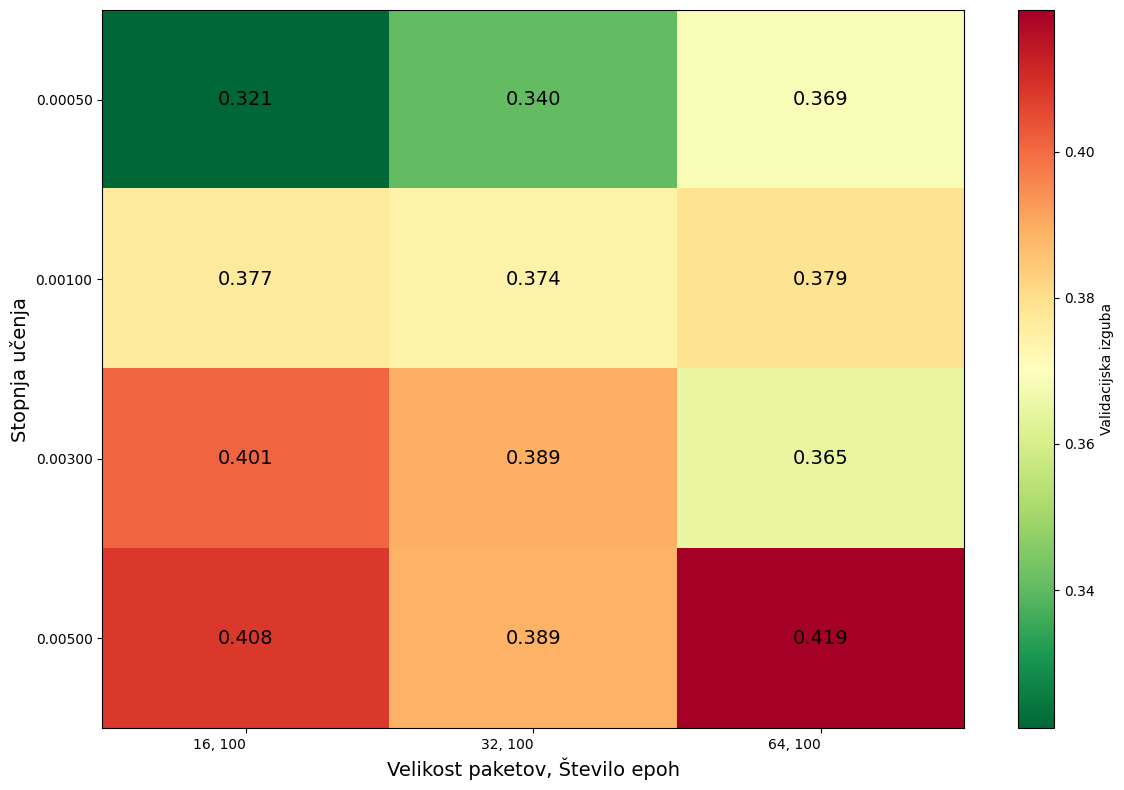

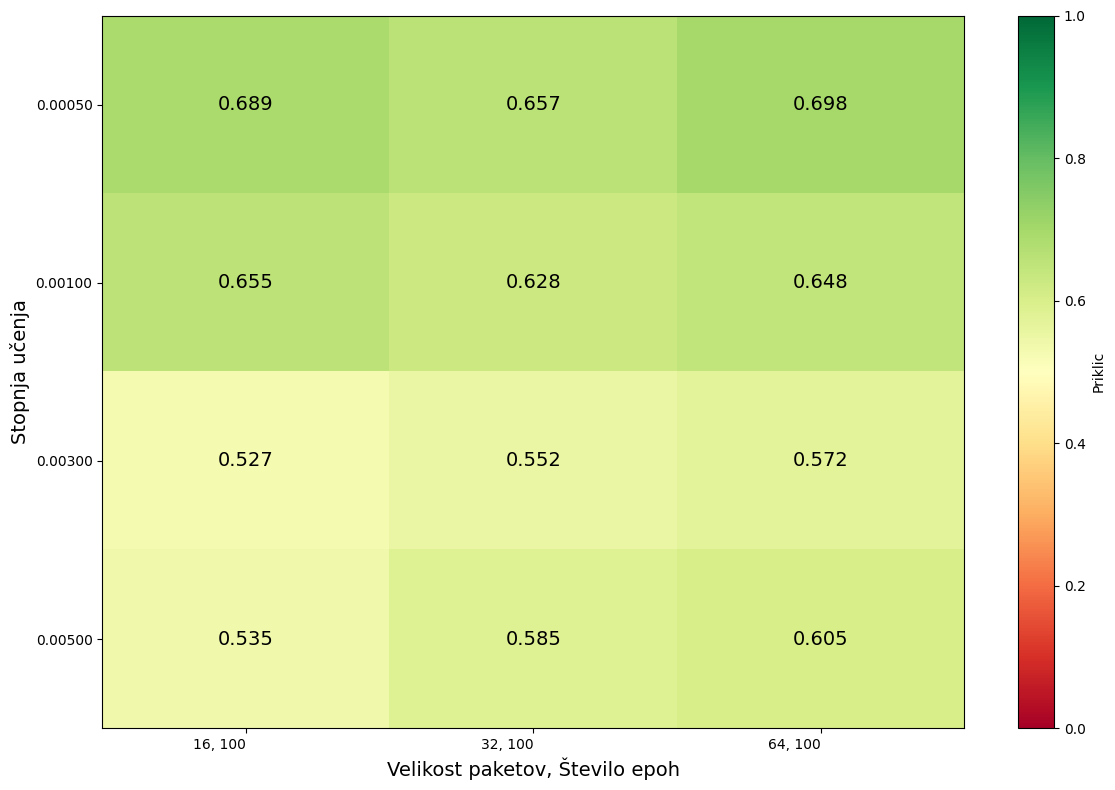

In [27]:
# Draw heatmaps
graph_font = 14
# ============================================================
# HEATMAP 1: Končni train loss
# ============================================================
fig1, ax1 = plt.subplots(figsize=(12, 8))
im1 = ax1.imshow(train_loss_matrix, cmap='RdYlGn_r', aspect='auto')

ax1.set_xticks(np.arange(len(combinations)))
ax1.set_yticks(np.arange(len(learning_rates)))
ax1.set_xticklabels(combination_labels, ha='right')
ax1.set_yticklabels([f'{lr:.5f}' for lr in learning_rates])

ax1.set_xlabel('Velikost paketov, Število epoh', fontsize=graph_font)
ax1.set_ylabel('Stopnja učenja', fontsize=graph_font)

# Številke v celicah
for i in range(len(learning_rates)):
    for j in range(len(combinations)):
        if not np.isnan(train_loss_matrix[i, j]):
            ax1.text(j, i, f'{train_loss_matrix[i, j]:.3f}',
                     ha="center", va="center", fontsize=graph_font)

plt.colorbar(im1, ax=ax1, label='Učna izguba')
plt.tight_layout()
plt.show()

# ============================================================
# HEATMAP 2: Končni validation loss
# ============================================================
fig2, ax2 = plt.subplots(figsize=(12, 8))
im2 = ax2.imshow(val_loss_matrix, cmap='RdYlGn_r', aspect='auto')

ax2.set_xticks(np.arange(len(combinations)))
ax2.set_yticks(np.arange(len(learning_rates)))
ax2.set_xticklabels(combination_labels, ha='right')
ax2.set_yticklabels([f'{lr:.5f}' for lr in learning_rates])

ax2.set_xlabel('Velikost paketov, Število epoh', fontsize=graph_font)
ax2.set_ylabel('Stopnja učenja', fontsize=graph_font)

for i in range(len(learning_rates)):
    for j in range(len(combinations)):
        if not np.isnan(val_loss_matrix[i, j]):
            ax2.text(j, i, f'{val_loss_matrix[i, j]:.3f}',
                     ha="center", va="center", fontsize=graph_font)

plt.colorbar(im2, ax=ax2, label='Validacijska izguba')
plt.tight_layout()
plt.show()

# ============================================================
# HEATMAP 3: Recall
# ============================================================
fig3, ax3 = plt.subplots(figsize=(12, 8))
im3 = ax3.imshow(recall_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

ax3.set_xticks(np.arange(len(combinations)))
ax3.set_yticks(np.arange(len(learning_rates)))
ax3.set_xticklabels(combination_labels, ha='right')
ax3.set_yticklabels([f'{lr:.5f}' for lr in learning_rates])

ax3.set_xlabel('Velikost paketov, Število epoh', fontsize=graph_font)
ax3.set_ylabel('Stopnja učenja', fontsize=graph_font)

for i in range(len(learning_rates)):
    for j in range(len(combinations)):
        if not np.isnan(recall_matrix[i, j]):
            ax3.text(j, i, f'{recall_matrix[i, j]:.3f}',
                     ha="center", va="center", fontsize=graph_font)

plt.colorbar(im3, ax=ax3, label='Priklic')
plt.tight_layout()
plt.show()